<a href="https://colab.research.google.com/github/yas2218/U.S.-Incarceration-Trend-Analysis/blob/main/USIncarcerationRatesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows: 1327797 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): state, county_name, urbanicity, region, division, pop_category
dbl (3): year, population, prison_population

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Call:
lm(formula = rate_per_100k ~ year, data = prison_trends)

Residuals:
     Min       1Q   Median       3Q      Max 
-157.294  -10.770   -4.362   28.898   62.087 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -17230.275   2580.243  -6.678  6.6e-07 ***
year             8.850      1.289   6.868  4.2e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 49.28 on 24 degrees of freedom
Multiple R-squared:  0.6628,	Adjusted R-squared:  0.6488 
F-statistic: 47.18 on 1 and 24 DF,  p-value: 4.198e-07



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


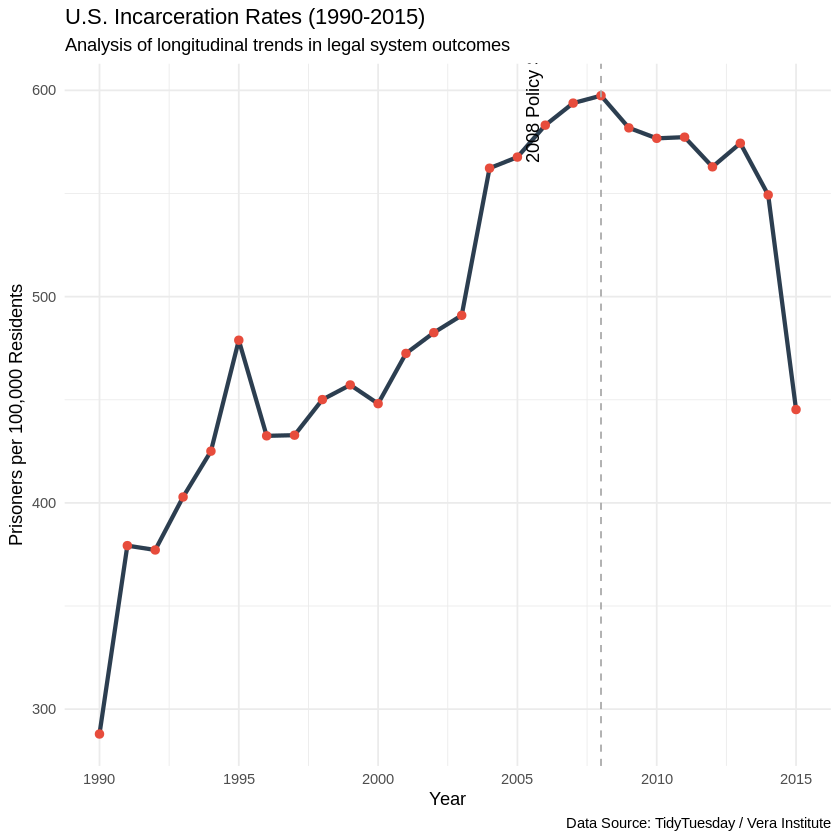

In [3]:
if (!require("tidyverse")) install.packages("tidyverse")
library(tidyverse)

# DATA ACQUISITION
# dataset from TidyTuesday repository
url <- "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2019/2019-01-22/prison_population.csv"
raw_data <- read_csv(url)

# 3. Clean Data
# Focusing on the 1990-2015 window to observe the peak of the 'tough on crime' era
prison_trends <- raw_data %>%
  filter(year >= 1990 & year <= 2015) %>%
  group_by(year) %>%
  summarize(
    total_prison_pop = sum(prison_population, na.rm = TRUE),
    total_general_pop = sum(population, na.rm = TRUE)
  ) %>%
  mutate(rate_per_100k = (total_prison_pop / total_general_pop) * 100000)

# 4. Statistical Modeling
# Use a linear model to analyze the overall progression over time.
trend_model <- lm(rate_per_100k ~ year, data = prison_trends)
print(summary(trend_model))

# 5. Vizualization
# Identifying the 2008 'turning point' often associated with the Great Recession
# and subsequent shifts toward criminal justice reform.
trend_plot <- ggplot(prison_trends, aes(x = year, y = rate_per_100k)) +
  geom_line(color = "#2c3e50", size = 1.2) +
  geom_point(color = "#e74c3c", size = 2) +
  geom_vline(xintercept = 2008, linetype = "dashed", color = "darkgrey") +
  annotate("text", x = 2006, y = max(prison_trends$rate_per_100k),
           label = "2008 Policy Shift", angle = 90, vjust = -0.5) +
  labs(
    title = "U.S. Incarceration Rates (1990-2015)",
    subtitle = "Analysis of longitudinal trends in legal system outcomes",
    x = "Year",
    y = "Prisoners per 100,000 Residents",
    caption = "Data Source: TidyTuesday / Vera Institute"
  ) +
  theme_minimal()

# Display plot
print(trend_plot)

# Save output
ggsave("incarceration_trend_plot.png", plot = trend_plot, width = 8, height = 5)